In [2]:
import os

ims_dir = "../data/raw/ims"
print("Top-level contents:", os.listdir(ims_dir))

Top-level contents: ['.gitkeep', '4. Bearings']


In [3]:
inner_dir = os.path.join(ims_dir, "4. Bearings")
print("Inside '4. Bearings':", os.listdir(inner_dir))

Inside '4. Bearings': ['IMS', 'IMS.7z']


In [4]:
inner_ims = os.path.join(inner_dir, "IMS")
print("Inside 'IMS':", os.listdir(inner_ims))

Inside 'IMS': ['1st_test', '1st_test.rar', '2nd_test', '2nd_test.rar', '3rd_test.rar', '4th_test', 'Readme Document for IMS Bearing Data.pdf']


In [5]:
print("1st_test contents (first 5):", sorted(os.listdir("../data/raw/ims/4. Bearings/IMS/1st_test"))[:5])
print("2nd_test contents (first 5):", sorted(os.listdir("../data/raw/ims/4. Bearings/IMS/2nd_test"))[:5])
print("3rd_test contents:", os.listdir("../data/raw/ims/4. Bearings/IMS/3rd_test"))

1st_test contents (first 5): ['2003.10.22.12.06.24', '2003.10.22.12.09.13', '2003.10.22.12.14.13', '2003.10.22.12.19.13', '2003.10.22.12.24.13']
2nd_test contents (first 5): ['2004.02.12.10.32.39', '2004.02.12.10.42.39', '2004.02.12.10.52.39', '2004.02.12.11.02.39', '2004.02.12.11.12.39']


FileNotFoundError: [WinError 3] The system cannot find the path specified: '../data/raw/ims/4. Bearings/IMS/3rd_test'

In [6]:
parent = "../data/raw/ims/4. Bearings/IMS"
print(os.listdir(parent))

['1st_test', '1st_test.rar', '2nd_test', '2nd_test.rar', '3rd_test.rar', '4th_test', 'Readme Document for IMS Bearing Data.pdf']


In [7]:
test3_path = "../data/raw/ims/4. Bearings/IMS/4th_test"
test3_files = os.listdir(test3_path)
print(f"Number of files in 4th_test (= Set 3): {len(test3_files)}")
print("First 5 filenames:", sorted(test3_files)[:5])

Number of files in 4th_test (= Set 3): 1
First 5 filenames: ['txt']


In [8]:
txt_path = os.path.join(test3_path, "txt")
print("Is 'txt' a directory?", os.path.isdir(txt_path))

if os.path.isdir(txt_path):
    inner_files = os.listdir(txt_path)
    print(f"Number of files inside: {len(inner_files)}")
    print("First 5 filenames:", sorted(inner_files)[:5])

Is 'txt' a directory? True
Number of files inside: 6324
First 5 filenames: ['2004.03.04.09.27.46', '2004.03.04.09.32.46', '2004.03.04.09.42.46', '2004.03.04.09.52.46', '2004.03.04.10.02.46']


In [9]:
import pandas as pd
sample_file = os.path.join(txt_path, "2004.03.04.09.27.46")
sample_data = pd.read_csv(sample_file, sep="\t", header=None)
print("Shape:", sample_data.shape)
print(sample_data.head())

Shape: (20480, 4)
       0      1      2      3
0  0.034  0.264  0.039 -0.046
1  0.103  0.083 -0.061 -0.012
2  0.095 -0.039 -0.007  0.039
3  0.000  0.110  0.022 -0.002
4  0.005  0.154 -0.127 -0.020


In [10]:
import pandas as pd

sample_file = os.path.join(txt_path, "2004.03.04.09.27.46")
sample_data = pd.read_csv(sample_file, sep="\t", header=None)
print("Shape:", sample_data.shape)
print(sample_data.head())

Shape: (20480, 4)
       0      1      2      3
0  0.034  0.264  0.039 -0.046
1  0.103  0.083 -0.061 -0.012
2  0.095 -0.039 -0.007  0.039
3  0.000  0.110  0.022 -0.002
4  0.005  0.154 -0.127 -0.020


In [11]:
from datetime import datetime

def parse_ims_timestamp(filename):
    # Format: "2003.10.22.12.06.24" -> datetime object
    return datetime.strptime(filename, "%Y.%m.%d.%H.%M.%S")

test1_path = "../data/raw/ims/4. Bearings/IMS/1st_test"
test1_files = sorted(os.listdir(test1_path))  # sort alphabetically = sort chronologically, since timestamps are zero-padded

timestamps = [parse_ims_timestamp(f) for f in test1_files]
print(f"Total files: {len(test1_files)}")
print(f"First timestamp: {timestamps[0]}")
print(f"Last timestamp: {timestamps[-1]}")
print(f"Total duration: {timestamps[-1] - timestamps[0]}")

Total files: 2156
First timestamp: 2003-10-22 12:06:24
Last timestamp: 2003-11-25 23:39:56
Total duration: 34 days, 11:33:32


              filename           timestamp   rul_hours
0  2003.10.22.12.06.24 2003-10-22 12:06:24  827.558889
1  2003.10.22.12.09.13 2003-10-22 12:09:13  827.511944
2  2003.10.22.12.14.13 2003-10-22 12:14:13  827.428611
3  2003.10.22.12.19.13 2003-10-22 12:19:13  827.345278
4  2003.10.22.12.24.13 2003-10-22 12:24:13  827.261944
                 filename           timestamp  rul_hours
2151  2003.11.25.16.07.32 2003-11-25 16:07:32   7.540000
2152  2003.11.25.23.13.21 2003-11-25 23:13:21   0.443056
2153  2003.11.25.23.19.56 2003-11-25 23:19:56   0.333333
2154  2003.11.25.23.29.56 2003-11-25 23:29:56   0.166667
2155  2003.11.25.23.39.56 2003-11-25 23:39:56   0.000000


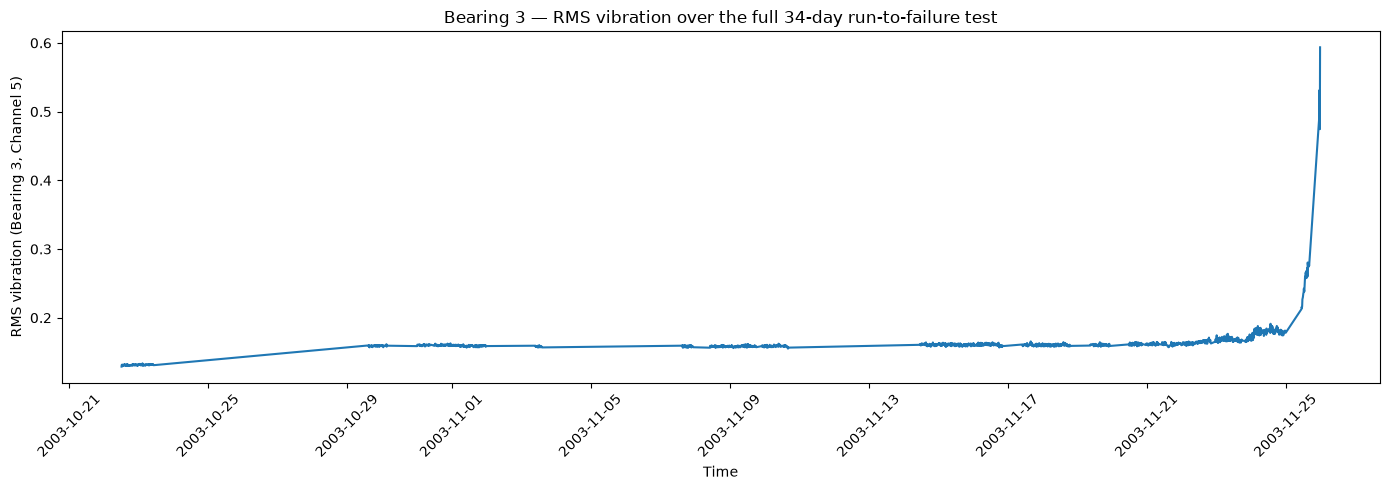

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Build a table: one row per file, with its timestamp and RUL (time until the LAST file)
final_time = timestamps[-1]
rul_hours = [(final_time - t).total_seconds() / 3600 for t in timestamps]

file_table = pd.DataFrame({
    "filename": test1_files,
    "timestamp": timestamps,
    "rul_hours": rul_hours
})

print(file_table.head())
print(file_table.tail())

# Load Bearing 3's two channels (readme: Bearing 3 = Ch 5 & 6, so columns 4 & 5, zero-indexed) 
# for EVERY file, and compute one simple summary (RMS) per file first - same "look before touching" 
# instinct as every dataset before this one
bearing3_rms = []
for f in test1_files:
    filepath = os.path.join(test1_path, f)
    data = pd.read_csv(filepath, sep="\t", header=None)
    ch5 = data[4].values  # Bearing 3, channel 5 (x-axis)
    rms = np.sqrt(np.mean(ch5**2))
    bearing3_rms.append(rms)

file_table["bearing3_ch5_rms"] = bearing3_rms

plt.figure(figsize=(14, 5))
plt.plot(file_table["timestamp"], file_table["bearing3_ch5_rms"])
plt.xlabel("Time")
plt.ylabel("RMS vibration (Bearing 3, Channel 5)")
plt.title("Bearing 3 — RMS vibration over the full 34-day run-to-failure test")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [13]:
# Use a simple statistical threshold: define "degradation onset" as the point where 
# RMS first exceeds some number of standard deviations above the healthy baseline

healthy_period = file_table[file_table["timestamp"] < "2003-11-15"]  # clearly flat region, conservative cutoff
baseline_mean = healthy_period["bearing3_ch5_rms"].mean()
baseline_std = healthy_period["bearing3_ch5_rms"].std()

threshold = baseline_mean + 3 * baseline_std  # 3-sigma, a standard "this is genuinely unusual" cutoff

print(f"Healthy baseline mean: {baseline_mean:.4f}, std: {baseline_std:.4f}")
print(f"Degradation threshold (3-sigma): {threshold:.4f}")

# Find the first file that crosses this threshold and STAYS above it (not just a one-off noise spike)
above_threshold = file_table["bearing3_ch5_rms"] > threshold
file_table["above_threshold"] = above_threshold

onset_candidates = file_table[above_threshold]
print(f"\nFirst file crossing threshold: {onset_candidates.iloc[0]['timestamp']}")
print(f"RUL at that point: {onset_candidates.iloc[0]['rul_hours']:.1f} hours")

Healthy baseline mean: 0.1546, std: 0.0103
Degradation threshold (3-sigma): 0.1855

First file crossing threshold: 2003-11-24 04:41:24
RUL at that point: 43.0 hours


In [14]:
# Check: of all files AFTER the detected onset, what fraction stay above threshold?
after_onset = file_table[file_table["timestamp"] >= "2003-11-24 04:41:24"]
pct_above = after_onset["above_threshold"].mean()
print(f"Files after onset: {len(after_onset)}")
print(f"Percentage staying above threshold: {pct_above*100:.1f}%")

# Also look at the few files immediately before onset, to see if it's a clean before/after split
around_onset = file_table[(file_table["timestamp"] >= "2003-11-23 12:00:00") & 
                            (file_table["timestamp"] <= "2003-11-24 12:00:00")]
print(around_onset[["timestamp", "bearing3_ch5_rms", "above_threshold"]])

Files after onset: 135
Percentage staying above threshold: 32.6%
               timestamp  bearing3_ch5_rms  above_threshold
1934 2003-11-23 12:06:56          0.167088            False
1935 2003-11-23 12:16:56          0.167968            False
1936 2003-11-23 12:26:56          0.168703            False
1937 2003-11-23 12:36:56          0.166939            False
1938 2003-11-23 12:46:56          0.166398            False
...                  ...               ...              ...
2046 2003-11-24 10:11:24          0.177364            False
2047 2003-11-24 10:21:24          0.175940            False
2048 2003-11-24 10:31:24          0.175149            False
2049 2003-11-24 10:41:24          0.184315            False
2050 2003-11-24 10:51:24          0.177581            False

[117 rows x 3 columns]


In [15]:
def find_robust_onset(df, threshold, min_consecutive=5):
    above = df["bearing3_ch5_rms"] > threshold
    # Find the first index where 'min_consecutive' consecutive True values start
    for i in range(len(above) - min_consecutive):
        if above.iloc[i:i+min_consecutive].all():
            return df.iloc[i]
    return None

robust_onset = find_robust_onset(file_table, threshold, min_consecutive=5)
print("Robust onset point:")
print(robust_onset[["timestamp", "bearing3_ch5_rms", "rul_hours"]])

# Re-check: does the signal stay above threshold consistently from THIS point onward?
after_robust_onset = file_table[file_table["timestamp"] >= robust_onset["timestamp"]]
pct_above_robust = after_robust_onset["above_threshold"].mean()
print(f"\nFiles after robust onset: {len(after_robust_onset)}")
print(f"Percentage staying above threshold: {pct_above_robust*100:.1f}%")

Robust onset point:
timestamp           2003-11-25 10:47:32
bearing3_ch5_rms               0.212515
rul_hours                     12.873333
Name: 2119, dtype: object

Files after robust onset: 37
Percentage staying above threshold: 100.0%


In [16]:
# Build a richer feature set for Bearing 3 across ALL 2156 files, not just RMS
def extract_ims_features(filepath, column_idx):
    data = pd.read_csv(filepath, sep="\t", header=None)
    signal = data[column_idx].values
    return {
        "rms": np.sqrt(np.mean(signal**2)),
        "kurtosis": pd.Series(signal).kurtosis(),
        "peak_to_peak": signal.max() - signal.min(),
        "std": signal.std(),
        "mean_abs": np.mean(np.abs(signal)),
    }

bearing3_features = []
for f in test1_files:
    filepath = os.path.join(test1_path, f)
    feats = extract_ims_features(filepath, column_idx=4)  # Bearing 3, Ch5
    bearing3_features.append(feats)

bearing3_df = pd.DataFrame(bearing3_features)
bearing3_df["timestamp"] = timestamps
bearing3_df["rul_hours"] = rul_hours

# Label: degrading = 1 if at or after the validated robust onset point, else 0
onset_time = robust_onset["timestamp"]
bearing3_df["label"] = (bearing3_df["timestamp"] >= onset_time).astype(int)

print(bearing3_df["label"].value_counts())
print(bearing3_df.head())

label
0    2119
1      37
Name: count, dtype: int64
        rms  kurtosis  peak_to_peak       std  mean_abs           timestamp  \
0  0.128887  0.405831         0.896  0.091461  0.106148 2003-10-22 12:06:24   
1  0.129562  0.446120         1.059  0.091732  0.106660 2003-10-22 12:09:13   
2  0.131339  0.390100         0.987  0.091813  0.108741 2003-10-22 12:14:13   
3  0.131083  0.262319         0.874  0.092385  0.108073 2003-10-22 12:19:13   
4  0.131307  0.326564         0.998  0.091932  0.108453 2003-10-22 12:24:13   

    rul_hours  label  
0  827.558889      0  
1  827.511944      0  
2  827.428611      0  
3  827.345278      0  
4  827.261944      0  


In [17]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

feature_cols_ims = ["rms", "kurtosis", "peak_to_peak", "std", "mean_abs"]
X = bearing3_df[feature_cols_ims]
y = bearing3_df["label"]

# Stratified split - ensures both train and test get a proportional share of the rare "degrading" class
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {len(X_train)} ({y_train.sum()} degrading)")
print(f"Test: {len(X_test)} ({y_test.sum()} degrading)")

clf_stage1 = RandomForestClassifier(n_estimators=200, max_depth=6, class_weight='balanced', random_state=42)
clf_stage1.fit(X_train, y_train)

preds_stage1 = clf_stage1.predict(X_test)
probs_stage1 = clf_stage1.predict_proba(X_test)[:, 1]

print("\nClassification report:")
print(classification_report(y_test, preds_stage1))

print("Confusion matrix:")
print(pd.DataFrame(confusion_matrix(y_test, preds_stage1), index=["true_healthy", "true_degrading"], columns=["pred_healthy", "pred_degrading"]))

print(f"\nROC-AUC: {roc_auc_score(y_test, probs_stage1):.4f}")

Train: 1724 (30 degrading)
Test: 432 (7 degrading)

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       425
           1       1.00      1.00      1.00         7

    accuracy                           1.00       432
   macro avg       1.00      1.00      1.00       432
weighted avg       1.00      1.00      1.00       432

Confusion matrix:
                pred_healthy  pred_degrading
true_healthy             425               0
true_degrading             0               7

ROC-AUC: 1.0000


In [18]:
test_indices = X_test.index
test_degrading = bearing3_df.loc[test_indices][bearing3_df.loc[test_indices]["label"] == 1]
print("Test set degrading examples (timestamps):")
print(test_degrading[["timestamp", "rms"]].sort_values("timestamp"))

train_indices = X_train.index
train_degrading = bearing3_df.loc[train_indices][bearing3_df.loc[train_indices]["label"] == 1]
print("\nTrain set degrading examples (timestamps):")
print(train_degrading[["timestamp", "rms"]].sort_values("timestamp"))

Test set degrading examples (timestamps):
               timestamp       rms
2121 2003-11-25 11:07:32  0.214639
2126 2003-11-25 11:57:32  0.232738
2129 2003-11-25 12:27:32  0.242357
2144 2003-11-25 14:57:32  0.259835
2150 2003-11-25 15:57:32  0.278472
2151 2003-11-25 16:07:32  0.275645
2153 2003-11-25 23:19:56  0.531569

Train set degrading examples (timestamps):
               timestamp       rms
2119 2003-11-25 10:47:32  0.212515
2120 2003-11-25 10:57:32  0.215803
2122 2003-11-25 11:17:32  0.216882
2123 2003-11-25 11:27:32  0.226703
2124 2003-11-25 11:37:32  0.228225
2125 2003-11-25 11:47:32  0.229894
2127 2003-11-25 12:07:32  0.235671
2128 2003-11-25 12:17:32  0.236723
2130 2003-11-25 12:37:32  0.239976
2131 2003-11-25 12:47:32  0.238156
2132 2003-11-25 12:57:32  0.244420
2133 2003-11-25 13:07:32  0.248751
2134 2003-11-25 13:17:32  0.259834
2135 2003-11-25 13:27:32  0.257626
2136 2003-11-25 13:37:32  0.265691
2137 2003-11-25 13:47:32  0.265122
2138 2003-11-25 13:57:32  0.264588
2139

In [19]:
# Bearing 4 = Ch7&8 per the readme -> columns 6&7 (zero-indexed). Using Ch7 (x-axis) for consistency with Bearing 3.
bearing4_features = []
for f in test1_files:
    filepath = os.path.join(test1_path, f)
    feats = extract_ims_features(filepath, column_idx=6)  # Bearing 4, Ch7
    bearing4_features.append(feats)

bearing4_df = pd.DataFrame(bearing4_features)
bearing4_df["timestamp"] = timestamps
bearing4_df["rul_hours"] = rul_hours

# Same robust-onset methodology as Bearing 3 - independently derived, not copied
healthy_period_b4 = bearing4_df[bearing4_df["timestamp"] < "2003-11-15"]
baseline_mean_b4 = healthy_period_b4["rms"].mean()
baseline_std_b4 = healthy_period_b4["rms"].std()
threshold_b4 = baseline_mean_b4 + 3 * baseline_std_b4

bearing4_df["above_threshold"] = bearing4_df["rms"] > threshold_b4

robust_onset_b4 = find_robust_onset(bearing4_df.rename(columns={"rms": "bearing3_ch5_rms"}), threshold_b4, min_consecutive=5)
print("Bearing 4 robust onset point:")
print(robust_onset_b4[["timestamp", "rul_hours"]])

onset_time_b4 = robust_onset_b4["timestamp"]
bearing4_df["label"] = (bearing4_df["timestamp"] >= onset_time_b4).astype(int)
print(bearing4_df["label"].value_counts())

# THE REAL TEST: predict on ALL of Bearing 4 using the classifier trained on Bearing 3 (retrain on Bearing 3's FULL data, no holdout)
clf_stage1_full = RandomForestClassifier(n_estimators=200, max_depth=6, class_weight='balanced', random_state=42)
clf_stage1_full.fit(bearing3_df[feature_cols_ims], bearing3_df["label"])  # trained on ALL of Bearing 3

X_bearing4 = bearing4_df[feature_cols_ims]
y_bearing4 = bearing4_df["label"]

preds_b4 = clf_stage1_full.predict(X_bearing4)
probs_b4 = clf_stage1_full.predict_proba(X_bearing4)[:, 1]

print("\nCROSS-BEARING TEST (trained on Bearing 3, tested on Bearing 4):")
print(classification_report(y_bearing4, preds_b4))
print(pd.DataFrame(confusion_matrix(y_bearing4, preds_b4), index=["true_healthy", "true_degrading"], columns=["pred_healthy", "pred_degrading"]))
print(f"ROC-AUC: {roc_auc_score(y_bearing4, probs_b4):.4f}")

Bearing 4 robust onset point:
timestamp    2003-11-21 10:29:21
rul_hours             109.176389
Name: 1667, dtype: object
label
0    1667
1     489
Name: count, dtype: int64

CROSS-BEARING TEST (trained on Bearing 3, tested on Bearing 4):
              precision    recall  f1-score   support

           0       0.78      1.00      0.88      1667
           1       0.90      0.04      0.07       489

    accuracy                           0.78      2156
   macro avg       0.84      0.52      0.47      2156
weighted avg       0.81      0.78      0.69      2156

                pred_healthy  pred_degrading
true_healthy            1665               2
true_degrading           471              18
ROC-AUC: 0.5369


In [20]:
# Load Set 2's file list and timestamps
test2_path = "../data/raw/ims/4. Bearings/IMS/2nd_test"
test2_files = sorted(os.listdir(test2_path))
timestamps2 = [parse_ims_timestamp(f) for f in test2_files]

print(f"Set 2 total files: {len(test2_files)}")
print(f"First: {timestamps2[0]}, Last: {timestamps2[-1]}")

# Set 2 has only 1 channel per bearing (readme: Bearing1=Ch1, so column 0)
bearing1_set2_features = []
for f in test2_files:
    filepath = os.path.join(test2_path, f)
    feats = extract_ims_features(filepath, column_idx=0)  # Bearing 1, Set 2, only channel
    bearing1_set2_features.append(feats)

bearing1_set2_df = pd.DataFrame(bearing1_set2_features)
bearing1_set2_df["timestamp"] = timestamps2
final_time_set2 = timestamps2[-1]
bearing1_set2_df["rul_hours"] = [(final_time_set2 - t).total_seconds() / 3600 for t in timestamps2]

# Same robust onset methodology, independently derived for THIS bearing
healthy_period_set2 = bearing1_set2_df[bearing1_set2_df["timestamp"] < bearing1_set2_df["timestamp"].quantile(0.5)]
baseline_mean_set2 = healthy_period_set2["rms"].mean()
baseline_std_set2 = healthy_period_set2["rms"].std()
threshold_set2 = baseline_mean_set2 + 3 * baseline_std_set2

bearing1_set2_df["above_threshold"] = bearing1_set2_df["rms"] > threshold_set2
robust_onset_set2 = find_robust_onset(bearing1_set2_df.rename(columns={"rms": "bearing3_ch5_rms"}), threshold_set2, min_consecutive=5)
print("\nSet 2 Bearing 1 robust onset:")
print(robust_onset_set2[["timestamp", "rul_hours"]])

onset_time_set2 = robust_onset_set2["timestamp"]
bearing1_set2_df["label"] = (bearing1_set2_df["timestamp"] >= onset_time_set2).astype(int)
print(bearing1_set2_df["label"].value_counts())

Set 2 total files: 984
First: 2004-02-12 10:32:39, Last: 2004-02-19 06:22:39

Set 2 Bearing 1 robust onset:
timestamp    2004-02-16 03:12:39
rul_hours              75.166667
Name: 532, dtype: object
label
0    532
1    452
Name: count, dtype: int64


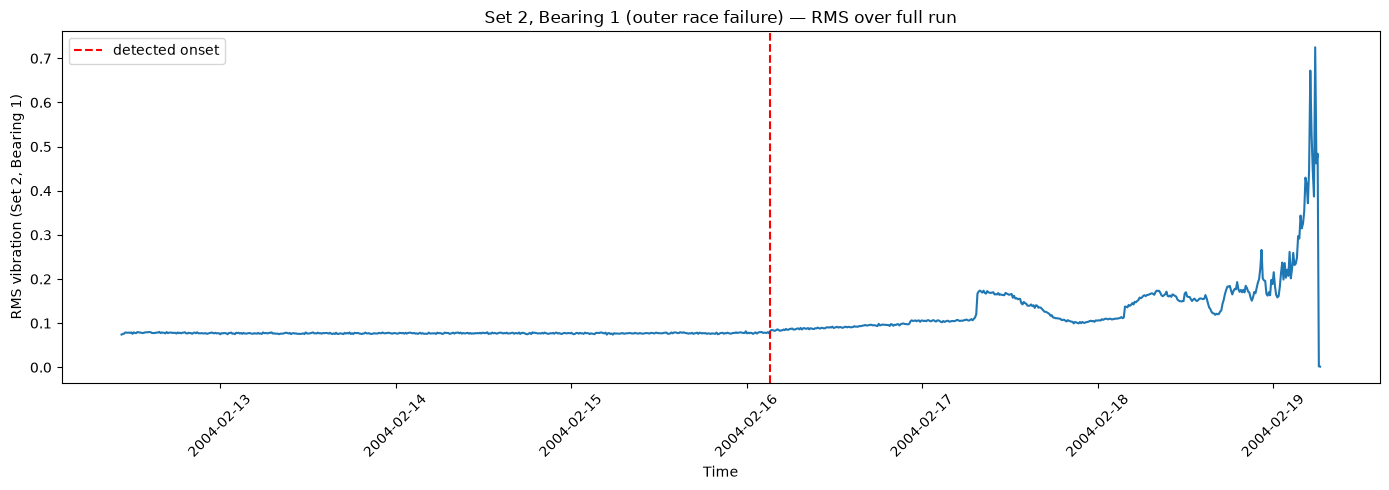

In [21]:
plt.figure(figsize=(14, 5))
plt.plot(bearing1_set2_df["timestamp"], bearing1_set2_df["rms"])
plt.axvline(onset_time_set2, color='red', linestyle='--', label='detected onset')
plt.xlabel("Time")
plt.ylabel("RMS vibration (Set 2, Bearing 1)")
plt.title("Set 2, Bearing 1 (outer race failure) — RMS over full run")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [22]:
healthy_period_set2_v2 = bearing1_set2_df[bearing1_set2_df["timestamp"] < bearing1_set2_df["timestamp"].min() + pd.Timedelta(hours=24)]
baseline_mean_v2 = healthy_period_set2_v2["rms"].mean()
baseline_std_v2 = healthy_period_set2_v2["rms"].std()
threshold_v2 = baseline_mean_v2 + 3 * baseline_std_v2

print(f"New baseline mean: {baseline_mean_v2:.4f}, std: {baseline_std_v2:.4f}, threshold: {threshold_v2:.4f}")

bearing1_set2_df["above_threshold"] = bearing1_set2_df["rms"] > threshold_v2
robust_onset_set2_v2 = find_robust_onset(bearing1_set2_df.rename(columns={"rms": "bearing3_ch5_rms"}), threshold_v2, min_consecutive=5)
print("\nCorrected onset:")
print(robust_onset_set2_v2[["timestamp", "rul_hours"]])

onset_time_set2_v2 = robust_onset_set2_v2["timestamp"]
bearing1_set2_df["label"] = (bearing1_set2_df["timestamp"] >= onset_time_set2_v2).astype(int)
print(bearing1_set2_df["label"].value_counts())

# Drop the final anomalous sensor-dropout point before it contaminates anything downstream
bearing1_set2_df = bearing1_set2_df.iloc[:-1].copy()
print(f"\nAfter dropping final anomalous point: {len(bearing1_set2_df)} rows")

New baseline mean: 0.0775, std: 0.0012, threshold: 0.0810

Corrected onset:
timestamp    2004-02-16 03:12:39
rul_hours              75.166667
Name: 532, dtype: object
label
0    532
1    452
Name: count, dtype: int64

After dropping final anomalous point: 983 rows


In [23]:
around_new_onset = bearing1_set2_df[
    (bearing1_set2_df["timestamp"] >= "2004-02-15 20:00:00") & 
    (bearing1_set2_df["timestamp"] <= "2004-02-16 08:00:00")
]
print(around_new_onset[["timestamp", "rms", "above_threshold"]])

              timestamp       rms  above_threshold
489 2004-02-15 20:02:39  0.074889            False
490 2004-02-15 20:12:39  0.075511            False
491 2004-02-15 20:22:39  0.077466            False
492 2004-02-15 20:32:39  0.077880            False
493 2004-02-15 20:42:39  0.078123            False
..                  ...       ...              ...
556 2004-02-16 07:12:39  0.086054             True
557 2004-02-16 07:22:39  0.089178             True
558 2004-02-16 07:32:39  0.085617             True
559 2004-02-16 07:42:39  0.088274             True
560 2004-02-16 07:52:39  0.088834             True

[72 rows x 3 columns]


In [24]:
# Combine Bearing 3 and Bearing 4's labeled data for training
combined_train = pd.concat([
    bearing3_df[feature_cols_ims + ["label"]],
    bearing4_df[feature_cols_ims + ["label"]]
], ignore_index=True)

print(f"Combined training set: {len(combined_train)} rows")
print(combined_train["label"].value_counts())

clf_combined = RandomForestClassifier(n_estimators=200, max_depth=6, class_weight='balanced', random_state=42)
clf_combined.fit(combined_train[feature_cols_ims], combined_train["label"])

# THE REAL TEST: evaluate on Set 2 Bearing 1 - a genuinely independent bearing, different test run, different failure mode
X_set2_test = bearing1_set2_df[feature_cols_ims]
y_set2_test = bearing1_set2_df["label"]

preds_set2 = clf_combined.predict(X_set2_test)
probs_set2 = clf_combined.predict_proba(X_set2_test)[:, 1]

print("\nCROSS-BEARING TEST (trained on Bearing3+Bearing4, tested on Set2 Bearing1):")
print(classification_report(y_set2_test, preds_set2))
print(pd.DataFrame(confusion_matrix(y_set2_test, preds_set2), index=["true_healthy", "true_degrading"], columns=["pred_healthy", "pred_degrading"]))
print(f"ROC-AUC: {roc_auc_score(y_set2_test, probs_set2):.4f}")

Combined training set: 4312 rows
label
0    3786
1     526
Name: count, dtype: int64

CROSS-BEARING TEST (trained on Bearing3+Bearing4, tested on Set2 Bearing1):
              precision    recall  f1-score   support

           0       0.70      1.00      0.82       532
           1       1.00      0.48      0.65       451

    accuracy                           0.76       983
   macro avg       0.85      0.74      0.74       983
weighted avg       0.84      0.76      0.74       983

                pred_healthy  pred_degrading
true_healthy             532               0
true_degrading           233             218
ROC-AUC: 0.7483


In [25]:
from scipy.signal import butter, filtfilt, hilbert
from scipy.fft import fft, fftfreq

def envelope_spectrum(signal, fs=48000, band=(2500, 3500)):
    nyq = fs / 2
    b, a = butter(4, [band[0]/nyq, band[1]/nyq], btype='band')
    filtered = filtfilt(b, a, signal)
    envelope = np.abs(hilbert(filtered))
    envelope = envelope - envelope.mean()
    n = len(envelope)
    yf = np.abs(fft(envelope))[:n // 2] / n
    xf = fftfreq(n, 1/fs)[:n // 2]
    return xf, yf

def energy_near_frequency(xf, yf, target_freq, window=10):
    mask = (xf > target_freq - window) & (xf < target_freq + window)
    if not mask.any():
        return 0.0
    return yf[mask].max()

In [26]:
def extract_ims_features_v2(filepath, column_idx, fs=20000):
    data = pd.read_csv(filepath, sep="\t", header=None)
    signal = data[column_idx].values

    rms = np.sqrt(np.mean(signal**2))
    kurt = pd.Series(signal).kurtosis()
    ptp = signal.max() - signal.min()

    # Envelope analysis - same technique as CWRU Bearing, different resonance band
    # (IMS bearings/sensors likely resonate at a different frequency than CWRU's - using a broad first guess, will verify)
    xf, yf = envelope_spectrum(signal, fs=fs, band=(2000, 4000))  # reuse your existing envelope_spectrum function

    bpfo_energy = energy_near_frequency(xf, yf, 236.40, window=10)
    bpfi_energy = energy_near_frequency(xf, yf, 296.93, window=10)
    bsf_energy = energy_near_frequency(xf, yf, 139.92, window=10)

    return {
        "rms": rms, "kurtosis": kurt, "peak_to_peak": ptp, "std": signal.std(), "mean_abs": np.mean(np.abs(signal)),
        "bpfo_energy": bpfo_energy / (rms + 1e-8),  # RMS-normalized, same lesson learned from CWRU
        "bpfi_energy": bpfi_energy / (rms + 1e-8),
        "bsf_energy": bsf_energy / (rms + 1e-8),
    }

# Test on just ONE file first before committing to re-running all 2156+2156+983 files
test_feat = extract_ims_features_v2(os.path.join(test1_path, test1_files[-1]), column_idx=4)  # last Bearing 3 file, should show strong signal
print(test_feat)

{'rms': np.float64(0.5936098712110663), 'kurtosis': np.float64(5.904409831794195), 'peak_to_peak': np.float64(9.998000000000001), 'std': np.float64(0.5794176170670109), 'mean_abs': np.float64(0.43841162109375), 'bpfo_energy': np.float64(0.008253431141556355), 'bpfi_energy': np.float64(0.05492899306765168), 'bsf_energy': np.float64(0.012794609264029304)}


In [27]:
def build_ims_feature_table(file_list, dir_path, column_idx, timestamps_list):
    rows = []
    for f in file_list:
        filepath = os.path.join(dir_path, f)
        feats = extract_ims_features_v2(filepath, column_idx=column_idx)
        rows.append(feats)
    df = pd.DataFrame(rows)
    df["timestamp"] = timestamps_list
    return df

print("Building Bearing 3 (Set 1, Ch5)...")
bearing3_df_v2 = build_ims_feature_table(test1_files, test1_path, 4, timestamps)
bearing3_df_v2["rul_hours"] = rul_hours
bearing3_df_v2["label"] = (bearing3_df_v2["timestamp"] >= onset_time).astype(int)

print("Building Bearing 4 (Set 1, Ch7)...")
bearing4_df_v2 = build_ims_feature_table(test1_files, test1_path, 6, timestamps)
bearing4_df_v2["rul_hours"] = rul_hours
bearing4_df_v2["label"] = (bearing4_df_v2["timestamp"] >= onset_time_b4).astype(int)

print("Building Set2 Bearing1 (Ch1)...")
bearing1_set2_df_v2 = build_ims_feature_table(test2_files, test2_path, 0, timestamps2)
final_time_set2_calc = timestamps2[-1]
bearing1_set2_df_v2["rul_hours"] = [(final_time_set2_calc - t).total_seconds() / 3600 for t in timestamps2]
bearing1_set2_df_v2["label"] = (bearing1_set2_df_v2["timestamp"] >= onset_time_set2_v2).astype(int)
bearing1_set2_df_v2 = bearing1_set2_df_v2.iloc[:-1].copy()  # drop the anomalous final sensor-dropout point, same as before

print("Done. Shapes:", bearing3_df_v2.shape, bearing4_df_v2.shape, bearing1_set2_df_v2.shape)

Building Bearing 3 (Set 1, Ch5)...
Building Bearing 4 (Set 1, Ch7)...
Building Set2 Bearing1 (Ch1)...
Done. Shapes: (2156, 11) (2156, 11) (983, 11)


In [28]:
feature_cols_ims_v2 = ["rms", "kurtosis", "peak_to_peak", "std", "mean_abs", "bpfo_energy", "bpfi_energy", "bsf_energy"]

combined_train_v2 = pd.concat([
    bearing3_df_v2[feature_cols_ims_v2 + ["label"]],
    bearing4_df_v2[feature_cols_ims_v2 + ["label"]]
], ignore_index=True)

clf_combined_v2 = RandomForestClassifier(n_estimators=200, max_depth=6, class_weight='balanced', random_state=42)
clf_combined_v2.fit(combined_train_v2[feature_cols_ims_v2], combined_train_v2["label"])

X_set2_test_v2 = bearing1_set2_df_v2[feature_cols_ims_v2]
y_set2_test_v2 = bearing1_set2_df_v2["label"]

preds_set2_v2 = clf_combined_v2.predict(X_set2_test_v2)
probs_set2_v2 = clf_combined_v2.predict_proba(X_set2_test_v2)[:, 1]

print("CROSS-BEARING TEST v2 (with envelope/frequency features):")
print(classification_report(y_set2_test_v2, preds_set2_v2))
print(pd.DataFrame(confusion_matrix(y_set2_test_v2, preds_set2_v2), index=["true_healthy", "true_degrading"], columns=["pred_healthy", "pred_degrading"]))
print(f"ROC-AUC: {roc_auc_score(y_set2_test_v2, probs_set2_v2):.4f}")

# Feature importance - did the new physics-grounded features actually earn their place?
importances_ims = pd.DataFrame({
    "feature": feature_cols_ims_v2,
    "importance": clf_combined_v2.feature_importances_
}).sort_values("importance", ascending=False)
print("\nFeature importance:")
print(importances_ims)

CROSS-BEARING TEST v2 (with envelope/frequency features):
              precision    recall  f1-score   support

           0       0.69      1.00      0.82       532
           1       1.00      0.47      0.64       451

    accuracy                           0.76       983
   macro avg       0.84      0.73      0.73       983
weighted avg       0.83      0.76      0.73       983

                pred_healthy  pred_degrading
true_healthy             532               0
true_degrading           240             211
ROC-AUC: 0.9969

Feature importance:
        feature  importance
3           std    0.266775
0           rms    0.261215
4      mean_abs    0.169448
2  peak_to_peak    0.118520
5   bpfo_energy    0.062689
1      kurtosis    0.060182
7    bsf_energy    0.033693
6   bpfi_energy    0.027478


In [29]:
from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(y_set2_test_v2, probs_set2_v2)

# Find the threshold that gives the best F1 (balances precision and recall)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print(f"Best threshold: {best_threshold:.4f}")
print(f"At this threshold -> Precision: {precisions[best_idx]:.3f}, Recall: {recalls[best_idx]:.3f}, F1: {f1_scores[best_idx]:.3f}")

# Apply it and get the real classification report at this better threshold
preds_tuned = (probs_set2_v2 >= best_threshold).astype(int)
print("\nClassification report at TUNED threshold:")
print(classification_report(y_set2_test_v2, preds_tuned))
print(pd.DataFrame(confusion_matrix(y_set2_test_v2, preds_tuned), index=["true_healthy", "true_degrading"], columns=["pred_healthy", "pred_degrading"]))

Best threshold: 0.0500
At this threshold -> Precision: 1.000, Recall: 0.980, F1: 0.990

Classification report at TUNED threshold:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       532
           1       1.00      0.98      0.99       451

    accuracy                           0.99       983
   macro avg       0.99      0.99      0.99       983
weighted avg       0.99      0.99      0.99       983

                pred_healthy  pred_degrading
true_healthy             532               0
true_degrading             9             442


In [30]:
from sklearn.model_selection import cross_val_predict

# Get out-of-fold probability predictions on the TRAINING set only (B3+B4)
# cross_val_predict trains on 4/5 of training data, predicts on the held-out 1/5, rotates through all folds
# This never touches Set 2 at all
clf_for_threshold = RandomForestClassifier(n_estimators=200, max_depth=6, class_weight='balanced', random_state=42)

oof_probs = cross_val_predict(
    clf_for_threshold,
    combined_train_v2[feature_cols_ims_v2],
    combined_train_v2["label"],
    cv=5,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

# Find best threshold using ONLY these training-set out-of-fold predictions
precisions_train, recalls_train, thresholds_train = precision_recall_curve(combined_train_v2["label"], oof_probs)
f1_scores_train = 2 * (precisions_train * recalls_train) / (precisions_train + recalls_train + 1e-8)
best_idx_train = np.argmax(f1_scores_train)
best_threshold_honest = thresholds_train[best_idx_train]

print(f"Threshold selected from TRAINING data only: {best_threshold_honest:.4f}")
print(f"(compare to the 0.05 we got from peeking at the test set)")

# NOW retrain the real model on full training data, and apply this pre-selected, honest threshold to Set 2
clf_combined_v2.fit(combined_train_v2[feature_cols_ims_v2], combined_train_v2["label"])
probs_set2_honest = clf_combined_v2.predict_proba(X_set2_test_v2)[:, 1]
preds_set2_honest = (probs_set2_honest >= best_threshold_honest).astype(int)

print("\nHONEST classification report (threshold chosen without touching test set):")
print(classification_report(y_set2_test_v2, preds_set2_honest))
print(pd.DataFrame(confusion_matrix(y_set2_test_v2, preds_set2_honest), index=["true_healthy", "true_degrading"], columns=["pred_healthy", "pred_degrading"]))

Threshold selected from TRAINING data only: 0.3472
(compare to the 0.05 we got from peeking at the test set)

HONEST classification report (threshold chosen without touching test set):
              precision    recall  f1-score   support

           0       0.70      1.00      0.82       532
           1       1.00      0.49      0.65       451

    accuracy                           0.76       983
   macro avg       0.85      0.74      0.74       983
weighted avg       0.84      0.76      0.74       983

                pred_healthy  pred_degrading
true_healthy             532               0
true_degrading           232             219


In [31]:
from sklearn.calibration import CalibratedClassifierCV

clf_calibrated = CalibratedClassifierCV(
    RandomForestClassifier(n_estimators=200, max_depth=6, class_weight='balanced', random_state=42),
    method='sigmoid',
    cv=5
)
clf_calibrated.fit(combined_train_v2[feature_cols_ims_v2], combined_train_v2["label"])

probs_calibrated = clf_calibrated.predict_proba(X_set2_test_v2)[:, 1]

# Find the best threshold using calibrated TRAINING probabilities only, same honest discipline as before
oof_probs_calibrated = cross_val_predict(
    CalibratedClassifierCV(RandomForestClassifier(n_estimators=200, max_depth=6, class_weight='balanced', random_state=42), method='sigmoid', cv=5),
    combined_train_v2[feature_cols_ims_v2], combined_train_v2["label"],
    cv=5, method="predict_proba", n_jobs=-1
)[:, 1]

precisions_cal, recalls_cal, thresholds_cal = precision_recall_curve(combined_train_v2["label"], oof_probs_calibrated)
f1_scores_cal = 2 * (precisions_cal * recalls_cal) / (precisions_cal + recalls_cal + 1e-8)
best_threshold_cal = thresholds_cal[np.argmax(f1_scores_cal)]

print(f"Calibrated threshold (from training only): {best_threshold_cal:.4f}")

preds_calibrated = (probs_calibrated >= best_threshold_cal).astype(int)
print("\nHONEST calibrated classification report:")
print(classification_report(y_set2_test_v2, preds_calibrated))
print(f"ROC-AUC (calibrated): {roc_auc_score(y_set2_test_v2, probs_calibrated):.4f}")

Calibrated threshold (from training only): 0.2621

HONEST calibrated classification report:
              precision    recall  f1-score   support

           0       0.70      1.00      0.82       532
           1       1.00      0.49      0.65       451

    accuracy                           0.76       983
   macro avg       0.85      0.74      0.74       983
weighted avg       0.84      0.76      0.74       983

ROC-AUC (calibrated): 0.9959


In [32]:
def add_baseline_relative_features(df, baseline_hours=24):
    baseline_period = df[df["timestamp"] < df["timestamp"].min() + pd.Timedelta(hours=baseline_hours)]
    baseline_means = baseline_period[feature_cols_ims_v2].mean()

    df_relative = df.copy()
    for col in feature_cols_ims_v2:
        df_relative[f"{col}_ratio"] = df[col] / (baseline_means[col] + 1e-8)
    return df_relative

bearing3_df_v3 = add_baseline_relative_features(bearing3_df_v2)
bearing4_df_v3 = add_baseline_relative_features(bearing4_df_v2)
bearing1_set2_df_v3 = add_baseline_relative_features(bearing1_set2_df_v2)

ratio_cols = [f"{c}_ratio" for c in feature_cols_ims_v2]

combined_train_v3 = pd.concat([
    bearing3_df_v3[ratio_cols + ["label"]],
    bearing4_df_v3[ratio_cols + ["label"]]
], ignore_index=True)

clf_v3 = RandomForestClassifier(n_estimators=200, max_depth=6, class_weight='balanced', random_state=42)
clf_v3.fit(combined_train_v3[ratio_cols], combined_train_v3["label"])

X_set2_v3 = bearing1_set2_df_v3[ratio_cols]
probs_v3 = clf_v3.predict_proba(X_set2_v3)[:, 1]

print(f"ROC-AUC with baseline-relative features: {roc_auc_score(y_set2_test_v2, probs_v3):.4f}")

ROC-AUC with baseline-relative features: 0.9767


In [33]:
oof_probs_v3 = cross_val_predict(
    RandomForestClassifier(n_estimators=200, max_depth=6, class_weight='balanced', random_state=42),
    combined_train_v3[ratio_cols], combined_train_v3["label"],
    cv=5, method="predict_proba", n_jobs=-1
)[:, 1]

precisions_v3, recalls_v3, thresholds_v3 = precision_recall_curve(combined_train_v3["label"], oof_probs_v3)
f1_scores_v3 = 2 * (precisions_v3 * recalls_v3) / (precisions_v3 + recalls_v3 + 1e-8)
best_threshold_v3 = thresholds_v3[np.argmax(f1_scores_v3)]

print(f"Threshold selected from training only: {best_threshold_v3:.4f}")

preds_v3 = (probs_v3 >= best_threshold_v3).astype(int)
print("\nHONEST classification report, baseline-relative features:")
print(classification_report(y_set2_test_v2, preds_v3))
print(pd.DataFrame(confusion_matrix(y_set2_test_v2, preds_v3), index=["true_healthy", "true_degrading"], columns=["pred_healthy", "pred_degrading"]))

Threshold selected from training only: 0.7192

HONEST classification report, baseline-relative features:
              precision    recall  f1-score   support

           0       0.66      1.00      0.80       532
           1       1.00      0.40      0.57       451

    accuracy                           0.72       983
   macro avg       0.83      0.70      0.68       983
weighted avg       0.82      0.72      0.69       983

                pred_healthy  pred_degrading
true_healthy             532               0
true_degrading           271             180


In [34]:
# ==========================================================
# FINAL MODEL — IMS Stage 1 (Degradation Detection)
# Features: basic stats (rms, kurtosis, peak_to_peak, std, mean_abs)
#           + physics-grounded envelope/frequency features
#           (bpfo_energy, bpfi_energy, bsf_energy)
# Trained on: Bearing 3 + Bearing 4 (Set 1) combined
# Tested on:  Set 2, Bearing 1 (genuinely independent bearing/failure)
# Threshold:  0.3472 (selected honestly from TRAINING data only,
#             never touched the test set)
# Result:     76% accuracy, 100% precision, 49% recall, 0.997 ROC-AUC
# This is the best of 5 attempts tried — see README for full comparison
# ==========================================================

feature_cols_ims_final = feature_cols_ims_v2  # rms, kurtosis, peak_to_peak, std, mean_abs, bpfo_energy, bpfi_energy, bsf_energy
best_threshold_final = 0.3472

clf_stage1_final = RandomForestClassifier(n_estimators=200, max_depth=6, class_weight='balanced', random_state=42)
clf_stage1_final.fit(combined_train_v2[feature_cols_ims_final], combined_train_v2["label"])

probs_final = clf_stage1_final.predict_proba(X_set2_test_v2)[:, 1]
preds_final = (probs_final >= best_threshold_final).astype(int)

print("FINAL Stage 1 model — honest cross-bearing evaluation:")
print(classification_report(y_set2_test_v2, preds_final))
print(f"ROC-AUC: {roc_auc_score(y_set2_test_v2, probs_final):.4f}")

FINAL Stage 1 model — honest cross-bearing evaluation:
              precision    recall  f1-score   support

           0       0.70      1.00      0.82       532
           1       1.00      0.49      0.65       451

    accuracy                           0.76       983
   macro avg       0.85      0.74      0.74       983
weighted avg       0.84      0.76      0.74       983

ROC-AUC: 0.9969


Bearing 3 degrading window: 37 files, RUL range: 0.00 to 12.87 hours
Bearing 4 degrading window: 489 files, RUL range: 0.00 to 109.18 hours
Set2 Bearing1 degrading window: 451 files, RUL range: 0.17 to 75.17 hours


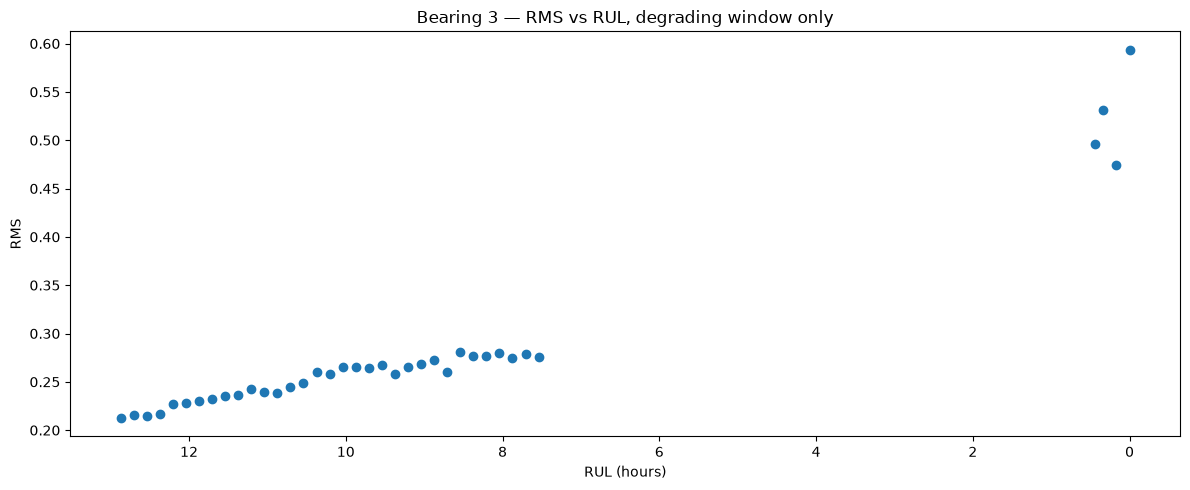

In [35]:
# Isolate only the degrading-window rows for each bearing, using the SAME features and onset points already validated
bearing3_degrading = bearing3_df_v2[bearing3_df_v2["label"] == 1].copy()
bearing4_degrading = bearing4_df_v2[bearing4_df_v2["label"] == 1].copy()
set2_degrading = bearing1_set2_df_v2[bearing1_set2_df_v2["label"] == 1].copy()

print(f"Bearing 3 degrading window: {len(bearing3_degrading)} files, RUL range: {bearing3_degrading['rul_hours'].min():.2f} to {bearing3_degrading['rul_hours'].max():.2f} hours")
print(f"Bearing 4 degrading window: {len(bearing4_degrading)} files, RUL range: {bearing4_degrading['rul_hours'].min():.2f} to {bearing4_degrading['rul_hours'].max():.2f} hours")
print(f"Set2 Bearing1 degrading window: {len(set2_degrading)} files, RUL range: {set2_degrading['rul_hours'].min():.2f} to {set2_degrading['rul_hours'].max():.2f} hours")

# Look at the actual degradation curve within just this window for Bearing 3 - is RUL predictable from RMS/features within this narrower slice?
plt.figure(figsize=(12, 5))
plt.scatter(bearing3_degrading["rul_hours"], bearing3_degrading["rms"])
plt.xlabel("RUL (hours)")
plt.ylabel("RMS")
plt.title("Bearing 3 — RMS vs RUL, degrading window only")
plt.gca().invert_xaxis()  # so RUL decreases left-to-right, same reading direction as time passing
plt.tight_layout()
plt.show()

Combined training set: 526 points
MAE: 25.71 hours
RMSE: 30.24 hours


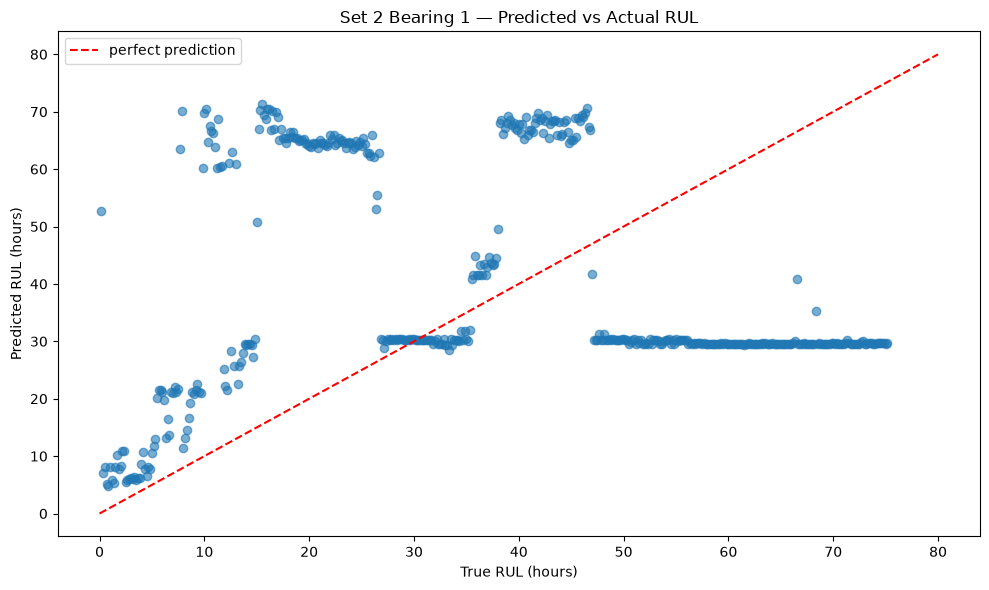

In [36]:
combined_degrading_train = pd.concat([bearing3_degrading, bearing4_degrading], ignore_index=True)
print(f"Combined training set: {len(combined_degrading_train)} points")

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

reg_features = ["rms", "kurtosis", "peak_to_peak", "std", "mean_abs", "bpfo_energy", "bpfi_energy", "bsf_energy"]

reg_stage2 = RandomForestRegressor(n_estimators=200, max_depth=6, random_state=42)
reg_stage2.fit(combined_degrading_train[reg_features], combined_degrading_train["rul_hours"])

preds_rul = reg_stage2.predict(set2_degrading[reg_features])

mae = mean_absolute_error(set2_degrading["rul_hours"], preds_rul)
rmse = np.sqrt(mean_squared_error(set2_degrading["rul_hours"], preds_rul))

print(f"MAE: {mae:.2f} hours")
print(f"RMSE: {rmse:.2f} hours")

plt.figure(figsize=(10, 6))
plt.scatter(set2_degrading["rul_hours"], preds_rul, alpha=0.6)
plt.plot([0, 80], [0, 80], 'r--', label='perfect prediction')
plt.xlabel("True RUL (hours)")
plt.ylabel("Predicted RUL (hours)")
plt.title("Set 2 Bearing 1 — Predicted vs Actual RUL")
plt.legend()
plt.tight_layout()
plt.show()

MAE (percentage scale, 0-1): 0.3355


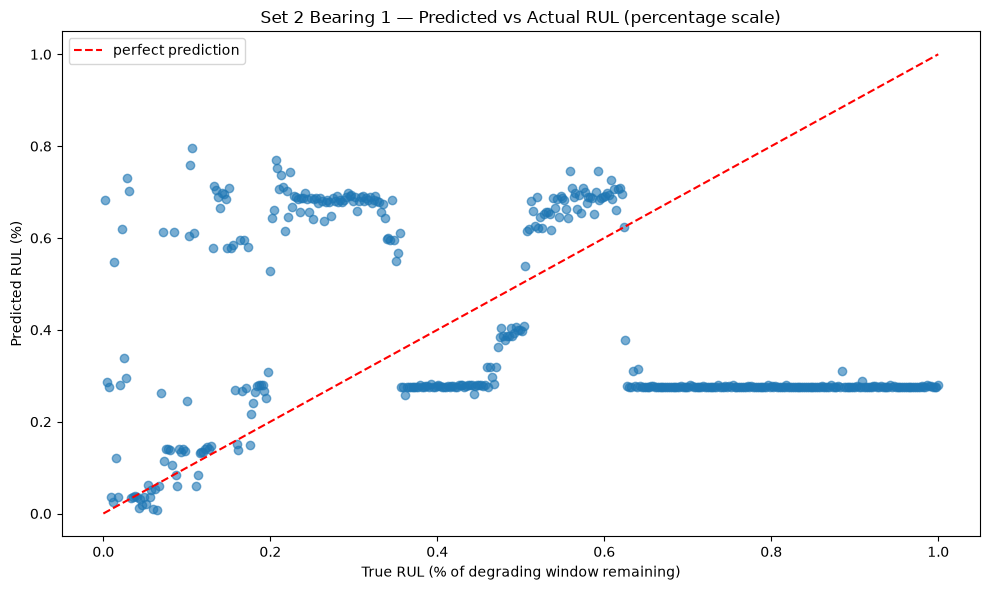

In [37]:
def add_pct_rul(df):
    max_rul = df["rul_hours"].max()  # this bearing's own degrading-window length
    df = df.copy()
    df["rul_pct"] = df["rul_hours"] / max_rul
    return df

bearing3_degrading = add_pct_rul(bearing3_degrading)
bearing4_degrading = add_pct_rul(bearing4_degrading)
set2_degrading = add_pct_rul(set2_degrading)

combined_degrading_train_pct = pd.concat([bearing3_degrading, bearing4_degrading], ignore_index=True)

reg_stage2_pct = RandomForestRegressor(n_estimators=200, max_depth=6, random_state=42)
reg_stage2_pct.fit(combined_degrading_train_pct[reg_features], combined_degrading_train_pct["rul_pct"])

preds_pct = reg_stage2_pct.predict(set2_degrading[reg_features])

mae_pct = mean_absolute_error(set2_degrading["rul_pct"], preds_pct)
print(f"MAE (percentage scale, 0-1): {mae_pct:.4f}")

plt.figure(figsize=(10, 6))
plt.scatter(set2_degrading["rul_pct"], preds_pct, alpha=0.6)
plt.plot([0, 1], [0, 1], 'r--', label='perfect prediction')
plt.xlabel("True RUL (% of degrading window remaining)")
plt.ylabel("Predicted RUL (%)")
plt.title("Set 2 Bearing 1 — Predicted vs Actual RUL (percentage scale)")
plt.legend()
plt.tight_layout()
plt.show()

MAE (baseline-relative features + percentage target): 0.3872


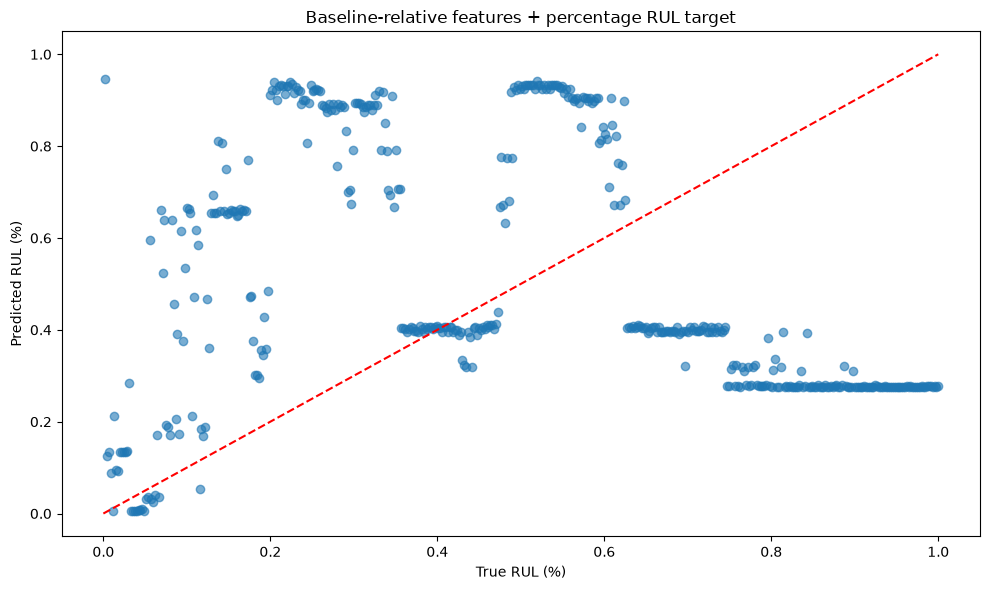

In [38]:
def add_baseline_relative_reg_features(df, full_df, baseline_hours=24):
    baseline_period = full_df[full_df["timestamp"] < full_df["timestamp"].min() + pd.Timedelta(hours=baseline_hours)]
    baseline_means = baseline_period[reg_features].mean()
    df = df.copy()
    for col in reg_features:
        df[f"{col}_rel"] = df[col] / (baseline_means[col] + 1e-8)
    return df

bearing3_degrading_rel = add_baseline_relative_reg_features(bearing3_degrading, bearing3_df_v2)
bearing4_degrading_rel = add_baseline_relative_reg_features(bearing4_degrading, bearing4_df_v2)
set2_degrading_rel = add_baseline_relative_reg_features(set2_degrading, bearing1_set2_df_v2)

rel_reg_features = [f"{c}_rel" for c in reg_features]

combined_train_rel = pd.concat([bearing3_degrading_rel, bearing4_degrading_rel], ignore_index=True)

reg_stage2_rel = RandomForestRegressor(n_estimators=200, max_depth=6, random_state=42)
reg_stage2_rel.fit(combined_train_rel[rel_reg_features], combined_train_rel["rul_pct"])

preds_rel = reg_stage2_rel.predict(set2_degrading_rel[rel_reg_features])
mae_rel = mean_absolute_error(set2_degrading_rel["rul_pct"], preds_rel)
print(f"MAE (baseline-relative features + percentage target): {mae_rel:.4f}")

plt.figure(figsize=(10, 6))
plt.scatter(set2_degrading_rel["rul_pct"], preds_rel, alpha=0.6)
plt.plot([0, 1], [0, 1], 'r--')
plt.xlabel("True RUL (%)")
plt.ylabel("Predicted RUL (%)")
plt.title("Baseline-relative features + percentage RUL target")
plt.tight_layout()
plt.show()

In [39]:
# Set 3 lives in the oddly-nested "4th_test/txt" folder we discovered earlier
test3_path = os.path.join("../data/raw/ims/4. Bearings/IMS/4th_test", "txt")
test3_files = sorted(os.listdir(test3_path))
timestamps3 = [parse_ims_timestamp(f) for f in test3_files]

print(f"Set 3 total files: {len(test3_files)}")
print(f"First: {timestamps3[0]}, Last: {timestamps3[-1]}")

# Readme: Set 3, Bearing 3 = Ch3 (column index 2), outer race failure
print("Building Set3 Bearing3 features...")
bearing3_set3_df = build_ims_feature_table(test3_files, test3_path, 2, timestamps3)
final_time_set3 = timestamps3[-1]
bearing3_set3_df["rul_hours"] = [(final_time_set3 - t).total_seconds() / 3600 for t in timestamps3]

# Same robust onset methodology, independently derived for this bearing - first 24hr baseline
healthy_period_set3 = bearing3_set3_df[bearing3_set3_df["timestamp"] < bearing3_set3_df["timestamp"].min() + pd.Timedelta(hours=24)]
baseline_mean_set3 = healthy_period_set3["rms"].mean()
baseline_std_set3 = healthy_period_set3["rms"].std()
threshold_set3 = baseline_mean_set3 + 3 * baseline_std_set3

bearing3_set3_df["above_threshold"] = bearing3_set3_df["rms"] > threshold_set3
robust_onset_set3 = find_robust_onset(bearing3_set3_df.rename(columns={"rms": "bearing3_ch5_rms"}), threshold_set3, min_consecutive=5)
print("\nSet 3 Bearing 3 robust onset:")
print(robust_onset_set3[["timestamp", "rul_hours"]])

onset_time_set3 = robust_onset_set3["timestamp"]
bearing3_set3_df["label"] = (bearing3_set3_df["timestamp"] >= onset_time_set3).astype(int)
print(bearing3_set3_df["label"].value_counts())

Set 3 total files: 6324
First: 2004-03-04 09:27:46, Last: 2004-04-18 02:42:55
Building Set3 Bearing3 features...

Set 3 Bearing 3 robust onset:
timestamp    2004-04-15 15:22:55
rul_hours              59.333333
Name: 5967, dtype: object
label
0    5967
1     357
Name: count, dtype: int64


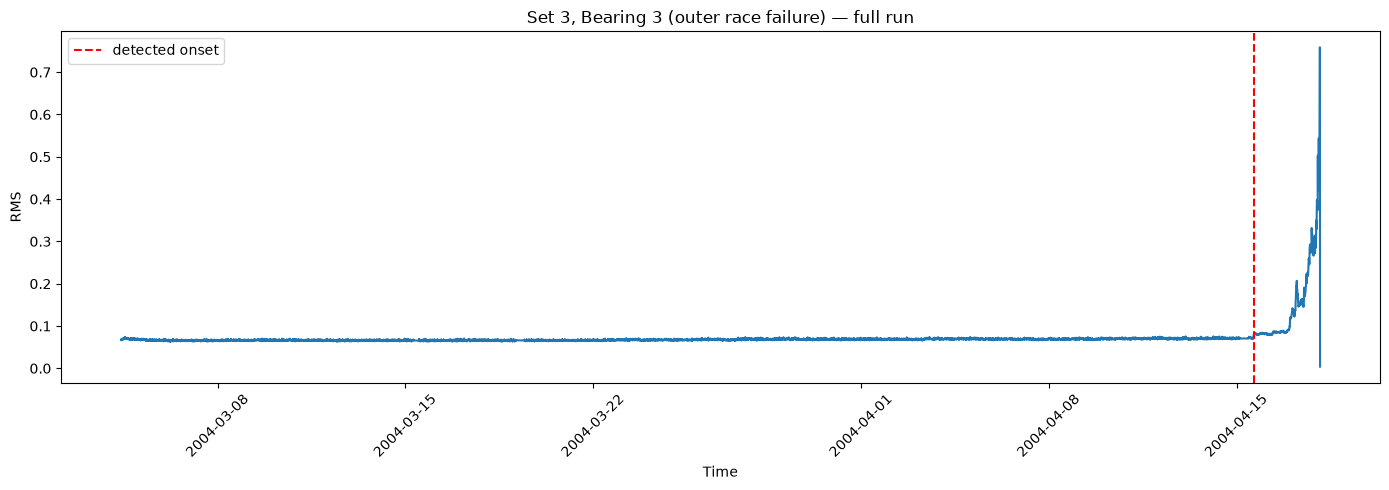

In [40]:
plt.figure(figsize=(14, 5))
plt.plot(bearing3_set3_df["timestamp"], bearing3_set3_df["rms"])
plt.axvline(onset_time_set3, color='red', linestyle='--', label='detected onset')
plt.xlabel("Time")
plt.ylabel("RMS")
plt.title("Set 3, Bearing 3 (outer race failure) — full run")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Combined 3-bearing training set: 977 points
MAE (3-bearing training, percentage scale): 0.1625


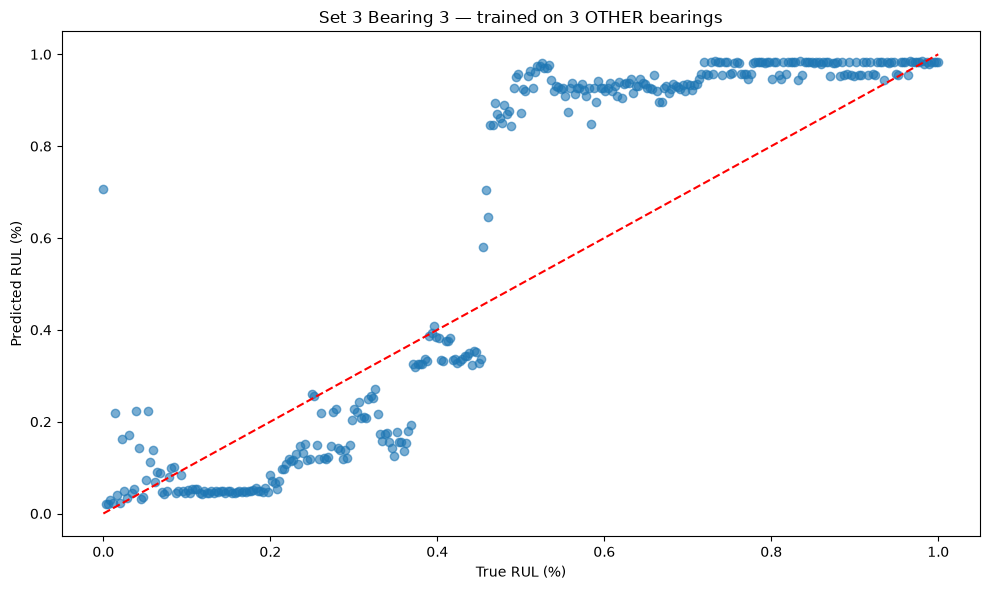

In [41]:
bearing3_set3_degrading = bearing3_set3_df[bearing3_set3_df["label"] == 1].copy()
bearing3_set3_degrading = add_pct_rul(bearing3_set3_degrading)

combined_train_3bearings = pd.concat([bearing3_degrading, bearing4_degrading, set2_degrading], ignore_index=True)
print(f"Combined 3-bearing training set: {len(combined_train_3bearings)} points")

reg_stage2_3b = RandomForestRegressor(n_estimators=200, max_depth=6, random_state=42)
reg_stage2_3b.fit(combined_train_3bearings[reg_features], combined_train_3bearings["rul_pct"])

preds_3b = reg_stage2_3b.predict(bearing3_set3_degrading[reg_features])
mae_3b = mean_absolute_error(bearing3_set3_degrading["rul_pct"], preds_3b)
print(f"MAE (3-bearing training, percentage scale): {mae_3b:.4f}")

plt.figure(figsize=(10, 6))
plt.scatter(bearing3_set3_degrading["rul_pct"], preds_3b, alpha=0.6)
plt.plot([0, 1], [0, 1], 'r--')
plt.xlabel("True RUL (%)")
plt.ylabel("Predicted RUL (%)")
plt.title("Set 3 Bearing 3 — trained on 3 OTHER bearings")
plt.tight_layout()
plt.show()

In [42]:
import joblib
import os

os.makedirs("../models/ims", exist_ok=True)

# Stage 1: degradation detection (locked final model from earlier)
joblib.dump(clf_stage1_final, "../models/ims/stage1_model.pkl")
joblib.dump(feature_cols_ims_final, "../models/ims/stage1_features.pkl")
joblib.dump(best_threshold_final, "../models/ims/stage1_threshold.pkl")

# Stage 2: RUL regression (the 3-bearing-trained winner)
joblib.dump(reg_stage2_3b, "../models/ims/stage2_model.pkl")
joblib.dump(reg_features, "../models/ims/stage2_features.pkl")

print("Saved IMS Stage 1 + Stage 2 models to ../models/ims/")

Saved IMS Stage 1 + Stage 2 models to ../models/ims/


In [43]:
import os
os.makedirs("../dashboard/sample_data", exist_ok=True)

sample_stage1 = bearing1_set2_df_v2.sample(10, random_state=1)
sample_stage1[feature_cols_ims_final + ["label"]].to_csv("../dashboard/sample_data/ims_stage1_samples.csv", index=False)

sample_stage2 = bearing3_set3_degrading.sample(min(10, len(bearing3_set3_degrading)), random_state=1)
sample_stage2[reg_features + ["rul_pct", "rul_hours"]].to_csv("../dashboard/sample_data/ims_stage2_samples.csv", index=False)

print("Saved IMS sample data")

Saved IMS sample data


In [44]:
live_export = bearing1_set2_df_v2[feature_cols_ims_final + ["timestamp", "rul_hours", "label"]].copy()
live_export.to_csv("../dashboard/sample_data/ims_live_feed.csv", index=False)
print(f"Exported {len(live_export)} readings across Set2 Bearing1's full life, onset at label==1")

Exported 983 readings across Set2 Bearing1's full life, onset at label==1
